## Import

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import time
import numpy as np
import scipy.linalg as linalg
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
#import preprocess


device = 'cuda:1'

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Data generation

In [3]:
mi_level = "mid"
mi_array = {'low':1, 'mid':3, 'high':7, 'very_high':9}
latent = False

mi = mi_array[mi_level]

In [8]:
from dr.Autoencoder import Autoencoder
from utils import utils_os


# [A]. Train autoencoder to compress data
if not os.path.isfile(f'results/images/gaussian_ae_X_{mi_level}.npy'):
    print('compression does not exist; train autoencoder')

    ae = Autoencoder(x_dim=d//2, y_dim=d//2, latent_size=8, alpha=1, lam=0)

    ae.to(device)
    X, Y = X.to(device).float(), Y.to(device).float()
    ae.learn(X, Y)
    
    XX, YY = ae.encode(X, Y)
    XX, YY = XX.clone().detach(), YY.clone().detach()

    utils_os.save_object('results/images', f'gaussian_ae_X_{mi_level}.npy', XX.detach().cpu().numpy())
    utils_os.save_object('results/images', f'gaussian_ae_Y_{mi_level}.npy', YY.detach().cpu().numpy())

# [B]. File exist; load previous compression
else:
    print('compression already exist; loading .npy files')

    XX = utils_os.load_object('results/images', f'gaussian_ae_X_{mi_level}.npy')
    YY = utils_os.load_object('results/images', f'gaussian_ae_Y_{mi_level}.npy')
    XX, YY = torch.Tensor(XX).clone().detach().to(device), torch.Tensor(YY).clone().detach().to(device)

n, d = torch.cat([XX, YY], dim=1).size()

X, Y = XX, YY

compression already exist; loading .npy files


## Train the VCE estimator

In [9]:
class Hyperparams(object):
    def __init__(self): 
        self.critic = 'neural'                # ('neural', 'quadratic')
        self.lr = 5e-4
        self.bs = 500
        self.n_bridges = 4
        self.wd = 1e-5
        self.max_iteration = 1250
        
hyperparams=Hyperparams()

architecture_critic = [d, 500, 500, 500, 1]

In [10]:
## Neural adaptive MI estimate
from estimators.VCE import VCE

estimator = VCE(None, None, architecture_critic, hyperparams)
estimator.to(device)
estimator.learn(X, Y)

print('true MI:', mi)
print('est MI:', estimator.MI(X, Y))

K components= 5 copula transform= True
nde type: FM
finished: t= 0 loss= 1.5204365253448486 loss val= 1.5641069412231445 best val loss= 1.5641069412231445 best t= 0
finished: t= 126 loss= 0.5355957746505737 loss val= 0.5073010921478271 best val loss= 0.4882025718688965 best t= 103
finished: t= 252 loss= 0.4733598828315735 loss val= 0.48238739371299744 best val loss= 0.4791845679283142 best t= 203
finished: t= 378 loss= 0.49910634756088257 loss val= 0.496959924697876 best val loss= 0.47521236538887024 best t= 306
finished: t= 504 loss= 0.45448416471481323 loss val= 0.5005249977111816 best val loss= 0.46955543756484985 best t= 488
finished: t= 630 loss= 0.4828892946243286 loss val= 0.49045026302337646 best val loss= 0.4626576900482178 best t= 617
finished: t= 756 loss= 0.5013867616653442 loss val= 0.4951181411743164 best val loss= 0.4626576900482178 best t= 617


finished: t= 0 loss= 1.588539719581604 loss val= 1.4534276723861694 best val loss= 1.4534276723861694 best t= 0
finished: t= 1

### Check the computed vector ranks

In [13]:
import torch.distributions as distribution

XX, YY = estimator.forward(X, Y)

# Compute empirical ranks
sorted_data, idx = torch.sort(XX, dim=0)
_, idx2 = torch.sort(idx, dim=0)
U = (idx2.float()+1)/(len(XX)+1)   

# Compute covariance
zeros, ones = torch.zeros(XX.size()).to(XX.device), torch.ones(XX.size()).to(XX.device)
U = (U-U.mean(keepdim=True, dim=0))/U.std(keepdim=True, dim=0)


V = torch.matmul(U.t(), U)/(len(U)+1)

In [15]:
print(V)

tensor([[ 0.9998, -0.1743, -0.0067,  0.1946,  0.0276,  0.0935, -0.1486, -0.3211],
        [-0.1743,  0.9998,  0.2367, -0.1536, -0.3663,  0.1130, -0.1207,  0.2204],
        [-0.0067,  0.2367,  0.9998,  0.0314,  0.0028,  0.0750,  0.1197,  0.1178],
        [ 0.1946, -0.1536,  0.0314,  0.9998,  0.1553,  0.1609,  0.1085,  0.1661],
        [ 0.0276, -0.3663,  0.0028,  0.1553,  0.9998, -0.3087,  0.1270,  0.3437],
        [ 0.0935,  0.1130,  0.0750,  0.1609, -0.3087,  0.9998, -0.2421, -0.3648],
        [-0.1486, -0.1207,  0.1197,  0.1085,  0.1270, -0.2421,  0.9998,  0.1499],
        [-0.3211,  0.2204,  0.1178,  0.1661,  0.3437, -0.3648,  0.1499,  0.9998]],
       device='cuda:1')


### Visualizing the distributions of non-diagonal elements

56
mean abs 0.1946217146567397
q5 -0.36478927731513977
q95 0.23667147755622864


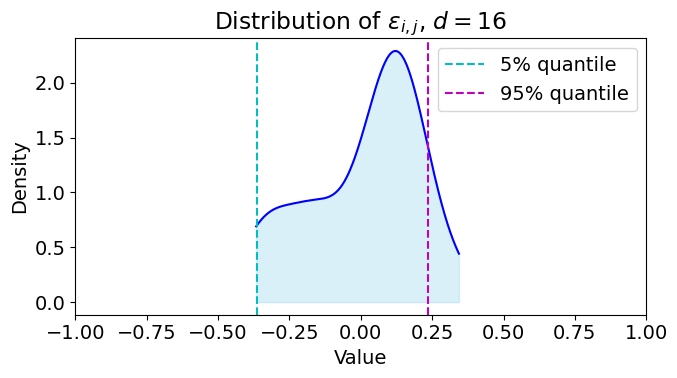

In [24]:
from scipy.stats import gaussian_kde

# Set global font size
plt.rcParams.update({'font.size': 14})

# Get non-diagonal elements of covariance matrices
non_diag_mask = ~torch.eye(V.size(0), dtype=bool, device=V.device)
non_diag_values = V[non_diag_mask]

# Convert to numpy
non_diag_np = non_diag_values.cpu().numpy()
sorted_vals = np.sort(non_diag_np)

# Compute ranks
L = len(sorted_vals)
print(L)
q5, q95 = sorted_vals[int(L * 0.05)], sorted_vals[int(L * 0.95)]
print('mean abs', (sorted_vals**2).mean()**0.5)
print('q5', q5.item())
print('q95', q95.item())

# KDE with scipy
kde = gaussian_kde(non_diag_np)
x_vals = np.linspace(min(non_diag_np), max(non_diag_np), 1000)
density = kde(x_vals)

# Plot
plt.figure(figsize=(7, 4))
plt.plot(x_vals, density, color='blue')
plt.fill_between(x_vals, density, alpha=0.3, color='skyblue')
plt.axvline(q5, color='c', linestyle='--', label='5% quantile')
plt.axvline(q95, color='m', linestyle='--', label='95% quantile')
plt.title(r'Distribution of $\epsilon_{i, j}$, $d=16$')
plt.xlim(-1, 1)
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig('vector_rank_quality_image_latent16D.png', dpi=300)
plt.show()
